# 🚇 FIAP — Dynamic Programming | Checkpoint 2

## 👥 Identificação do Grupo

| Nome | RA |
|------|----|
| Eduardo Bassan | RM561474 |
| Henry Andrade | RM562622 |
| Mariana S. do Egito Moreira | RM562544 |
| João Victor Abe | RM561446 |
| Deivid Ruan | RM566356 |

**Disciplina:** Dynamic Programming  
**Professor:** Andre Marques  
**Checkpoint:** 2 — Em Grupo  
**Entrega:** 04/05/2026


## 📋 Contexto e Hipóteses de Solução

### Problema
Construir um sistema de rotas para redes de metrô em **três metrópoles** (Beijing, San Francisco e São Paulo), modelando as redes como grafos ponderados e encontrando o **caminho mais curto** e o **caminho mais longo simples** (sem ciclos) entre estações distantes, com fatores de penalidade/bônus por horário.

### Hipóteses e Decisões de Modelagem

1. **Grafo não-dirigido:** Optamos por grafos não-dirigidos, pois as linhas de metrô normalmente operam nos dois sentidos com o mesmo custo/tempo entre estações adjacentes.

2. **Pesos das arestas:** Representam o tempo médio de viagem em minutos entre estações adjacentes, baseado em dados reais aproximados de cada rede.

3. **Fator de horário:** Aplicado multiplicativamente sobre todos os pesos antes da busca. O horário é global — mesma faixa para toda a viagem — simplificação razoável para trajetos curtos.

4. **Memoização:** Usamos `functools.lru_cache` com `frozenset` para os visitados. O caminho mais curto se beneficia muito; o mais longo (backtracking) tem natureza combinatória e memoização com efeito limitado — comparamos ambos.

5. **Caminho mais longo simples:** Implementado com backtracking recursivo, explorando todos os caminhos sem ciclos e selecionando o de maior custo total. Computacionalmente caro para grafos densos.

6. **Complexidade:**
   - Caminho mais curto com memoização: O(V × 2ᵛ) no pior caso, mas muito mais rápido na prática.
   - Caminho mais longo (backtracking): O(V!) no pior caso — exponencial.


## ⚙️ Imports e Dependências

In [1]:
import time
import tracemalloc
import functools
import folium
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from IPython.display import display, HTML

print("✅ Todas as bibliotecas carregadas com sucesso!")


✅ Todas as bibliotecas carregadas com sucesso!


## ⏰ Fatores de Horário — Penalidades e Bônus

| Faixa Horária | Fator | Justificativa |
|---------------|-------|---------------|
| 05h – 07h | × 0,6 | **Bônus:** metrô vazio, embarque rápido, sem filas |
| 07h – 09h | × 1,5 | Pico da manhã: volume moderado-alto |
| 09h – 17h | × 1,0 | Horário normal: fluxo regular |
| 17h – 20h | × 2,0 | **Penalidade máxima:** pico da tarde, lotação |
| Outros | × 1,0 | Fora do horário de operação intensa |


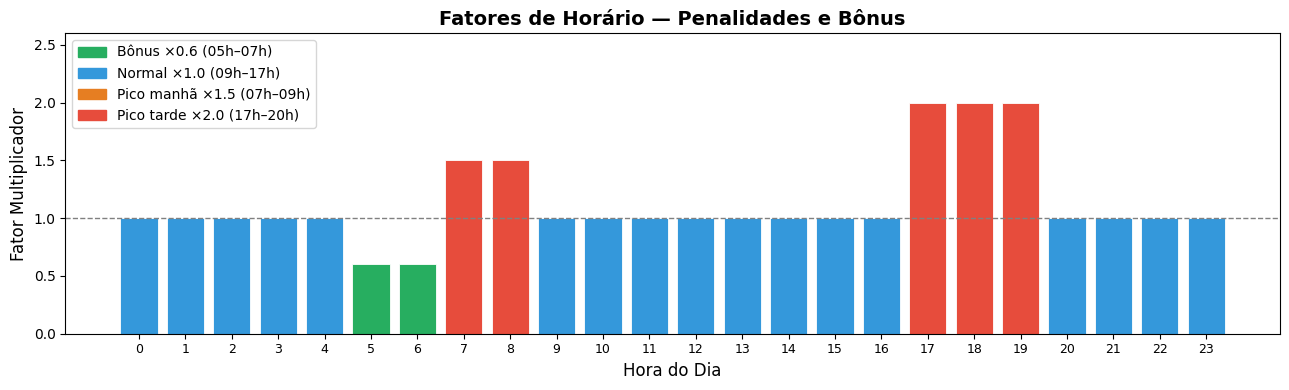

In [2]:
def fator_horario(hora: float) -> float:
    """Retorna o fator multiplicador de acordo com a hora do dia (0-23)."""
    if 5 <= hora < 7:
        return 0.6   # Bônus madrugada/manhã cedo
    elif 7 <= hora < 9:
        return 1.5   # Pico manhã
    elif 9 <= hora < 17:
        return 1.0   # Horário normal
    elif 17 <= hora < 20:
        return 2.0   # Pico tarde (maior penalidade)
    else:
        return 1.0   # Demais horários

# Visualização dos fatores ao longo do dia
horas  = list(range(0, 24))
fatores = [fator_horario(h) for h in horas]
cores   = ['#27ae60' if f < 1 else '#e74c3c' if f > 1.2 else '#e67e22' if f > 1 else '#3498db'
           for f in fatores]

plt.figure(figsize=(13, 4))
plt.bar(horas, fatores, color=cores, edgecolor='white', linewidth=0.6)
plt.axhline(1.0, color='gray', linestyle='--', linewidth=1)
plt.xlabel('Hora do Dia', fontsize=12)
plt.ylabel('Fator Multiplicador', fontsize=12)
plt.title('Fatores de Horário — Penalidades e Bônus', fontsize=14, fontweight='bold')
plt.xticks(horas, fontsize=9)
plt.ylim(0, 2.6)
patches = [
    mpatches.Patch(color='#27ae60', label='Bônus ×0.6 (05h–07h)'),
    mpatches.Patch(color='#3498db', label='Normal ×1.0 (09h–17h)'),
    mpatches.Patch(color='#e67e22', label='Pico manhã ×1.5 (07h–09h)'),
    mpatches.Patch(color='#e74c3c', label='Pico tarde ×2.0 (17h–20h)'),
]
plt.legend(handles=patches, fontsize=10)
plt.tight_layout()
plt.show()


## 🧠 Implementação dos Algoritmos

### Recursão + Memoização (Caminho Mais Curto)
Usamos `functools.lru_cache`. O estado memoizado é `(origem, destino, hora, frozenset(visitados))`.  
A cada estado único, o resultado é armazenado em cache — evitando recalcular subproblemas repetidos.

### Backtracking (Caminho Mais Longo Simples)
Exploramos todos os caminhos possíveis sem repetir nós, guardando o de maior custo total.  
Não há memoização eficaz aqui pois o resultado depende do conjunto exato de visitados em cada ramo.


In [3]:
def make_menor_custo(grafo):
    """Cria a função de menor custo com memoização para um grafo específico."""
    @functools.lru_cache(maxsize=None)
    def menor_custo(origem, destino, hora, visitados=frozenset()):
        if origem == destino:
            return 0, (origem,)
        fator = fator_horario(hora)
        melhor_custo = float('inf')
        melhor_caminho = None
        for vizinho, peso in grafo.get(origem, ()):
            if vizinho not in visitados:
                custo_r, cam_r = menor_custo(
                    vizinho, destino, hora, visitados | frozenset([origem])
                )
                custo_total = fator * peso + custo_r
                if custo_total < melhor_custo:
                    melhor_custo = custo_total
                    melhor_caminho = (origem,) + cam_r
        return melhor_custo, melhor_caminho if melhor_caminho else (origem,)
    return menor_custo


def menor_custo_sem_memo(grafo, origem, destino, hora, visitados=None):
    """Caminho mais curto SEM memoização (para comparação de desempenho)."""
    if visitados is None:
        visitados = set()
    if origem == destino:
        return 0, (origem,)
    fator = fator_horario(hora)
    melhor_custo = float('inf')
    melhor_caminho = None
    visitados.add(origem)
    for vizinho, peso in grafo.get(origem, ()):
        if vizinho not in visitados:
            custo_r, cam_r = menor_custo_sem_memo(grafo, vizinho, destino, hora, visitados)
            custo_total = fator * peso + custo_r
            if custo_total < melhor_custo:
                melhor_custo = custo_total
                melhor_caminho = (origem,) + cam_r
    visitados.discard(origem)
    return melhor_custo, melhor_caminho if melhor_caminho else (origem,)


def maior_custo(grafo, origem, destino, hora, visitados=None):
    """Caminho mais longo simples (sem ciclos) via backtracking."""
    if visitados is None:
        visitados = set()
    if origem == destino:
        return 0, (origem,)
    fator = fator_horario(hora)
    melhor_custo = float('-inf')
    melhor_caminho = None
    visitados.add(origem)
    for vizinho, peso in grafo.get(origem, ()):
        if vizinho not in visitados:
            custo_r, cam_r = maior_custo(grafo, vizinho, destino, hora, visitados)
            custo_total = fator * peso + custo_r
            if custo_total > melhor_custo:
                melhor_custo = custo_total
                melhor_caminho = (origem,) + cam_r
    visitados.discard(origem)
    return melhor_custo, melhor_caminho if melhor_caminho else (origem,)


def medir(funcao, *args, **kwargs):
    """Mede tempo de execução e pico de memória de uma função."""
    tracemalloc.start()
    t0 = time.perf_counter()
    resultado = funcao(*args, **kwargs)
    t1 = time.perf_counter()
    _, mem_peak = tracemalloc.get_traced_memory()
    tracemalloc.stop()
    return resultado, round(t1 - t0, 6), round(mem_peak / 1024, 2)

print("✅ Algoritmos definidos com sucesso!")


✅ Algoritmos definidos com sucesso!


## 🇧🇷 Cidade 1 — São Paulo (Metrô + CPTM)

**Origem:** Tucuruvi (Linha 1 — Azul) | **Destino:** Capão Redondo (Linha 5 — Lilás)  
**Horário:** 18h — Pico da tarde (fator ×2.0)  
**Integração obrigatória:** Passagem por estações de integração entre linhas (Sé, Ana Rosa, Santa Cruz).

O grafo cobre as Linhas 1 (Azul), 2 (Verde), 3 (Vermelha) e 5 (Lilás) com suas estações de transferência.


In [4]:
grafo_sp_dict = {
    # Linha 1 — Azul (Norte-Sul)
    "Tucuruvi":              [("Parada Inglesa", 2)],
    "Parada Inglesa":        [("Tucuruvi", 2), ("Jardim São Paulo", 2)],
    "Jardim São Paulo":      [("Parada Inglesa", 2), ("Santana", 2)],
    "Santana":               [("Jardim São Paulo", 2), ("Carandiru", 2)],
    "Carandiru":             [("Santana", 2), ("Portuguesa-Tietê", 2)],
    "Portuguesa-Tietê":      [("Carandiru", 2), ("Armênia", 2)],
    "Armênia":               [("Portuguesa-Tietê", 2), ("Tiradentes", 2)],
    "Tiradentes":            [("Armênia", 2), ("Luz", 2)],
    "Luz":                   [("Tiradentes", 2), ("São Bento", 2), ("Brás", 3)],
    "São Bento":             [("Luz", 2), ("Sé", 2)],
    "Sé":                    [("São Bento", 2), ("Liberdade", 2), ("Anhangabaú", 2)],
    "Liberdade":             [("Sé", 2), ("São Judas", 2)],
    "São Judas":             [("Liberdade", 2), ("Saúde", 2)],
    "Saúde":                 [("São Judas", 2), ("Praça da Árvore", 2)],
    "Praça da Árvore":       [("Saúde", 2), ("Santo Amaro", 8)],
    "Santo Amaro":           [("Praça da Árvore", 8), ("Largo Treze", 2), ("Giovanni Gronchi", 3)],
    "Largo Treze":           [("Santo Amaro", 2), ("Adolfo Pinheiro", 2)],
    "Adolfo Pinheiro":       [("Largo Treze", 2), ("Alto da Boa Vista", 2)],
    # Linha 2 — Verde
    "Vila Madalena":         [("Sumaré", 3)],
    "Sumaré":                [("Vila Madalena", 3), ("Clínicas", 2)],
    "Clínicas":              [("Sumaré", 2), ("Consolação", 2)],
    "Consolação":            [("Clínicas", 2), ("Trianon-Masp", 2), ("Paulista", 1)],
    "Paulista":              [("Consolação", 1), ("Brigadeiro", 2)],
    "Trianon-Masp":          [("Consolação", 2), ("Brigadeiro", 2)],
    "Brigadeiro":            [("Trianon-Masp", 2), ("Paraíso", 2)],
    "Paraíso":               [("Brigadeiro", 2), ("Ana Rosa", 2)],
    "Ana Rosa":              [("Paraíso", 2), ("Chácara Klabin", 2), ("Santa Cruz", 3)],
    "Chácara Klabin":        [("Ana Rosa", 2), ("Alto do Ipiranga", 2)],
    "Alto do Ipiranga":      [("Chácara Klabin", 2), ("Santos-Imigrantes", 2)],
    "Santos-Imigrantes":     [("Alto do Ipiranga", 2)],
    # Linha 3 — Vermelha
    "Palmeiras-Barra Funda": [("Marechal Deodoro", 2)],
    "Marechal Deodoro":      [("Palmeiras-Barra Funda", 2), ("Santa Cecília", 2)],
    "Santa Cecília":         [("Marechal Deodoro", 2), ("República", 2)],
    "República":             [("Santa Cecília", 2), ("Anhangabaú", 2)],
    "Anhangabaú":            [("República", 2), ("Sé", 2)],
    "Brás":                  [("Luz", 3), ("Tatuapé", 4)],
    "Tatuapé":               [("Brás", 4), ("Carrão", 2)],
    "Carrão":                [("Tatuapé", 2), ("Penha", 3)],
    "Penha":                 [("Carrão", 3), ("Vila Matilde", 2)],
    "Vila Matilde":          [("Penha", 2), ("Guilhermina-Esperança", 2)],
    "Guilhermina-Esperança": [("Vila Matilde", 2), ("Patriarca", 2)],
    "Patriarca":             [("Guilhermina-Esperança", 2), ("Arthur Alvim", 2)],
    "Arthur Alvim":          [("Patriarca", 2), ("Corinthians-Itaquera", 3)],
    "Corinthians-Itaquera":  [("Arthur Alvim", 3)],
    # Linha 5 — Lilás
    "Capão Redondo":         [("Campo Limpo", 3)],
    "Campo Limpo":           [("Capão Redondo", 3), ("Vila das Belezas", 2)],
    "Vila das Belezas":      [("Campo Limpo", 2), ("Giovanni Gronchi", 2)],
    "Giovanni Gronchi":      [("Vila das Belezas", 2), ("Santo Amaro", 3)],
    "Alto da Boa Vista":     [("Adolfo Pinheiro", 2), ("Borba Gato", 2)],
    "Borba Gato":            [("Alto da Boa Vista", 2), ("Brooklin", 2)],
    "Brooklin":              [("Borba Gato", 2), ("República do Líbano", 2)],
    "República do Líbano":   [("Brooklin", 2), ("Eucaliptos", 2)],
    "Eucaliptos":            [("República do Líbano", 2), ("Moema", 2)],
    "Moema":                 [("Eucaliptos", 2), ("AACD-Server", 2)],
    "AACD-Server":           [("Moema", 2), ("Hospital São Paulo", 2)],
    "Hospital São Paulo":    [("AACD-Server", 2), ("Santa Cruz", 2)],
    "Santa Cruz":            [("Hospital São Paulo", 2), ("Ana Rosa", 3)],
}

grafo_sp = {k: tuple(v) for k, v in grafo_sp_dict.items()}
ORIGEM_SP, DESTINO_SP, HORA_SP = "Tucuruvi", "Capão Redondo", 18

fn_sp = make_menor_custo(grafo_sp)
(custo_sp_c, cam_sp_c), t_sp_c, mem_sp_c = medir(fn_sp, ORIGEM_SP, DESTINO_SP, HORA_SP)
(custo_sp_s, cam_sp_s), t_sp_s, mem_sp_s = medir(menor_custo_sem_memo, grafo_sp, ORIGEM_SP, DESTINO_SP, HORA_SP)
(custo_sp_l, cam_sp_l), t_sp_l, mem_sp_l = medir(maior_custo, grafo_sp, ORIGEM_SP, DESTINO_SP, HORA_SP)

print(f"🇧🇷 São Paulo — Fator horário: ×{fator_horario(HORA_SP)}")
print(f"   MAIS CURTO  ({len(cam_sp_c)} est.): {' → '.join(cam_sp_c)}")
print(f"   Custo: {custo_sp_c:.1f} min  |  Tempo: {t_sp_c:.5f}s  |  Mem: {mem_sp_c:.1f} KB")
print()
print(f"   MAIS LONGO  ({len(cam_sp_l)} est.): {' → '.join(cam_sp_l)}")
print(f"   Custo: {custo_sp_l:.1f} min")
print(f"   Nós no grafo SP: {len(grafo_sp)}")


🇧🇷 São Paulo — Fator horário: ×2.0
   MAIS CURTO  (20 est.): Tucuruvi → Parada Inglesa → Jardim São Paulo → Santana → Carandiru → Portuguesa-Tietê → Armênia → Tiradentes → Luz → São Bento → Sé → Liberdade → São Judas → Saúde → Praça da Árvore → Santo Amaro → Giovanni Gronchi → Vila das Belezas → Campo Limpo → Capão Redondo
   Custo: 92.0 min  |  Tempo: 0.00074s  |  Mem: 60.4 KB

   MAIS LONGO  (20 est.): Tucuruvi → Parada Inglesa → Jardim São Paulo → Santana → Carandiru → Portuguesa-Tietê → Armênia → Tiradentes → Luz → São Bento → Sé → Liberdade → São Judas → Saúde → Praça da Árvore → Santo Amaro → Giovanni Gronchi → Vila das Belezas → Campo Limpo → Capão Redondo
   Custo: 92.0 min
   Nós no grafo SP: 57


### 🗺️ Mapa Interativo — São Paulo

- 🔴 Marcador vermelho = Origem (Tucuruvi)  
- 🟢 Marcador verde = Destino (Capão Redondo)  
- **Linha vermelha** = Caminho mais curto  
- **Linha laranja** = Caminho mais longo  
- Cinza = demais conexões do grafo


In [5]:
coords_sp = {
    "Tucuruvi":              (-23.4734, -46.6072),
    "Parada Inglesa":        (-23.4839, -46.6106),
    "Jardim São Paulo":      (-23.4960, -46.6145),
    "Santana":               (-23.5037, -46.6267),
    "Carandiru":             (-23.5102, -46.6270),
    "Portuguesa-Tietê":      (-23.5154, -46.6264),
    "Armênia":               (-23.5196, -46.6288),
    "Tiradentes":            (-23.5299, -46.6321),
    "Luz":                   (-23.5357, -46.6338),
    "São Bento":             (-23.5421, -46.6336),
    "Sé":                    (-23.5497, -46.6338),
    "Liberdade":             (-23.5574, -46.6337),
    "São Judas":             (-23.5648, -46.6315),
    "Saúde":                 (-23.5715, -46.6287),
    "Praça da Árvore":       (-23.5789, -46.6256),
    "Santo Amaro":           (-23.6497, -46.7072),
    "Largo Treze":           (-23.6557, -46.7124),
    "Adolfo Pinheiro":       (-23.6626, -46.7086),
    "Vila Madalena":         (-23.5479, -46.6916),
    "Sumaré":                (-23.5447, -46.6739),
    "Clínicas":              (-23.5542, -46.6693),
    "Consolação":            (-23.5570, -46.6582),
    "Paulista":              (-23.5617, -46.6532),
    "Trianon-Masp":          (-23.5618, -46.6548),
    "Brigadeiro":            (-23.5647, -46.6508),
    "Paraíso":               (-23.5711, -46.6481),
    "Ana Rosa":              (-23.5813, -46.6430),
    "Chácara Klabin":        (-23.5869, -46.6330),
    "Alto do Ipiranga":      (-23.5893, -46.6216),
    "Santos-Imigrantes":     (-23.5889, -46.6097),
    "Palmeiras-Barra Funda": (-23.5264, -46.6626),
    "Marechal Deodoro":      (-23.5333, -46.6514),
    "Santa Cecília":         (-23.5377, -46.6468),
    "República":             (-23.5418, -46.6437),
    "Anhangabaú":            (-23.5453, -46.6408),
    "Brás":                  (-23.5415, -46.6213),
    "Tatuapé":               (-23.5431, -46.5763),
    "Carrão":                (-23.5478, -46.5631),
    "Penha":                 (-23.5262, -46.5419),
    "Vila Matilde":          (-23.5354, -46.5247),
    "Guilhermina-Esperança": (-23.5429, -46.5105),
    "Patriarca":             (-23.5491, -46.4983),
    "Arthur Alvim":          (-23.5574, -46.4847),
    "Corinthians-Itaquera":  (-23.5451, -46.4558),
    "Capão Redondo":         (-23.6735, -46.7788),
    "Campo Limpo":           (-23.6664, -46.7618),
    "Vila das Belezas":      (-23.6574, -46.7489),
    "Giovanni Gronchi":      (-23.6530, -46.7378),
    "Alto da Boa Vista":     (-23.6583, -46.7239),
    "Borba Gato":            (-23.6540, -46.7141),
    "Brooklin":              (-23.6359, -46.7057),
    "República do Líbano":   (-23.6214, -46.6988),
    "Eucaliptos":            (-23.6077, -46.6846),
    "Moema":                 (-23.5968, -46.6720),
    "AACD-Server":           (-23.5890, -46.6619),
    "Hospital São Paulo":    (-23.5876, -46.6533),
    "Santa Cruz":            (-23.5853, -46.6453),
}

def build_map(coords, grafo, caminho_curto, caminho_longo, origem, destino,
              center, zoom, titulo):
    m = folium.Map(location=center, zoom_start=zoom, tiles='CartoDB positron')
    # Arestas gerais
    adicionadas = set()
    for est, vizs in grafo.items():
        if est not in coords: continue
        for viz, _ in vizs:
            if viz not in coords: continue
            par = tuple(sorted([est, viz]))
            if par not in adicionadas:
                folium.PolyLine([coords[est], coords[viz]],
                                color='#aaaaaa', weight=2, opacity=0.45).add_to(m)
                adicionadas.add(par)
    # Caminho mais longo (laranja, por baixo)
    for i in range(len(caminho_longo)-1):
        a, b = caminho_longo[i], caminho_longo[i+1]
        if a in coords and b in coords:
            folium.PolyLine([coords[a], coords[b]], color='#e67e22', weight=5,
                            opacity=0.85, tooltip=f"Longo: {a} → {b}").add_to(m)
    # Caminho mais curto (vermelho, por cima)
    for i in range(len(caminho_curto)-1):
        a, b = caminho_curto[i], caminho_curto[i+1]
        if a in coords and b in coords:
            folium.PolyLine([coords[a], coords[b]], color='#e74c3c', weight=6,
                            opacity=0.95, tooltip=f"Curto: {a} → {b}").add_to(m)
    # Marcadores
    for est, (lat, lon) in coords.items():
        if est == origem:
            folium.Marker([lat, lon], popup=f"🔴 ORIGEM: {est}",
                          icon=folium.Icon(color='red', icon='play', prefix='fa')).add_to(m)
        elif est == destino:
            folium.Marker([lat, lon], popup=f"🟢 DESTINO: {est}",
                          icon=folium.Icon(color='green', icon='flag', prefix='fa')).add_to(m)
        else:
            folium.CircleMarker([lat, lon], radius=5, color='#2980b9',
                                fill=True, fill_color='#2980b9',
                                fill_opacity=0.8, popup=est).add_to(m)
    # Legenda
    legend = f"""<div style="position:fixed;bottom:30px;left:30px;z-index:1000;
        background:white;padding:12px 16px;border-radius:10px;
        border:1px solid #ccc;font-size:13px;line-height:1.7;">
        <b>{titulo}</b><br>
        <span style="color:#e74c3c;font-weight:bold">━━</span> Caminho mais curto<br>
        <span style="color:#e67e22;font-weight:bold">━━</span> Caminho mais longo<br>
        <span style="color:#aaa">━━</span> Outras conexões
    </div>"""
    m.get_root().html.add_child(folium.Element(legend))
    return m

m_sp = build_map(coords_sp, grafo_sp, cam_sp_c, cam_sp_l,
                 ORIGEM_SP, DESTINO_SP, [-23.58, -46.66], 12,
                 "🇧🇷 São Paulo — Metrô + CPTM")
m_sp.save("mapa_sao_paulo.html")
print("✅ Mapa SP salvo: mapa_sao_paulo.html")
display(m_sp)


✅ Mapa SP salvo: mapa_sao_paulo.html


## 🇨🇳 Cidade 2 — Beijing (Metrô)

**Origem:** Sihui East (Linha 1) | **Destino:** Xizhimen (Linhas 2/4/13)  
**Horário:** 8h — Pico da manhã (fator ×1.5)  
**Linhas usadas:** 1, 2, 4 e 10 com estações de integração: Guomao, Jianguomen, Fuxingmen, Xizhimen.


In [6]:
grafo_bj_dict = {
    # Linha 1 — Leste-Oeste
    "Sihui East":        [("Sihui", 2)],
    "Sihui":             [("Sihui East", 2), ("Guomao", 3), ("Shilihe", 4)],
    "Guomao":            [("Sihui", 3), ("Yong'anli", 2), ("Jintaixizhao", 3)],
    "Yong'anli":         [("Guomao", 2), ("Jianguomen", 2)],
    "Jianguomen":        [("Yong'anli", 2), ("Dongdan", 2), ("Chaoyangmen", 3)],
    "Dongdan":           [("Jianguomen", 2), ("Wangfujing", 2)],
    "Wangfujing":        [("Dongdan", 2), ("Tiananmen East", 2)],
    "Tiananmen East":    [("Wangfujing", 2), ("Tiananmen West", 2)],
    "Tiananmen West":    [("Tiananmen East", 2), ("Xidan", 2)],
    "Xidan":             [("Tiananmen West", 2), ("Fuxingmen", 2), ("Xuanwumen", 2)],
    "Fuxingmen":         [("Xidan", 2), ("Muxidi", 2), ("Nanlishilu", 2), ("Fuchengmen", 2)],
    "Muxidi":            [("Fuxingmen", 2), ("Military Museum", 2)],
    "Military Museum":   [("Muxidi", 2), ("Wanshoulu", 3)],
    "Wanshoulu":         [("Military Museum", 3), ("Gongzhufen", 2)],
    "Gongzhufen":        [("Wanshoulu", 2), ("Babaoshan", 3)],
    "Babaoshan":         [("Gongzhufen", 3)],
    # Linha 2 — Circular Norte
    "Chaoyangmen":       [("Jianguomen", 3), ("Dongzhimen", 3)],
    "Dongzhimen":        [("Chaoyangmen", 3), ("Yonghegong", 3)],
    "Yonghegong":        [("Dongzhimen", 3), ("Andingmen", 2)],
    "Andingmen":         [("Yonghegong", 2), ("Guloudajie", 2)],
    "Guloudajie":        [("Andingmen", 2), ("Jishuitan", 3)],
    "Jishuitan":         [("Guloudajie", 3), ("Xizhimen", 2)],
    "Xizhimen":          [("Jishuitan", 2), ("Chegongzhuang", 3), ("Xinjiekou", 2)],
    "Xinjiekou":         [("Xizhimen", 2), ("Fuchengmen", 2)],
    "Fuchengmen":        [("Xinjiekou", 2), ("Fuxingmen", 2)],
    "Nanlishilu":        [("Fuxingmen", 2), ("Chegongzhuang", 3)],
    "Chegongzhuang":     [("Nanlishilu", 3), ("Xizhimen", 3)],
    # Linha 4 — Norte-Sul
    "Xuanwumen":         [("Xidan", 2), ("Caishikou", 2)],
    "Caishikou":         [("Xuanwumen", 2), ("Taoranting", 3)],
    "Taoranting":        [("Caishikou", 3)],
    # Linha 10 — Circular interna
    "Jintaixizhao":      [("Guomao", 3), ("Shuangjing", 3)],
    "Shuangjing":        [("Jintaixizhao", 3), ("Jinsong", 2)],
    "Jinsong":           [("Shuangjing", 2), ("Panjiayuan", 2)],
    "Panjiayuan":        [("Jinsong", 2), ("Shilihe", 3)],
    "Shilihe":           [("Panjiayuan", 3), ("Sihui", 4)],
}

grafo_bj = {k: tuple(v) for k, v in grafo_bj_dict.items()}
ORIGEM_BJ, DESTINO_BJ, HORA_BJ = "Sihui East", "Xizhimen", 8

fn_bj = make_menor_custo(grafo_bj)
(custo_bj_c, cam_bj_c), t_bj_c, mem_bj_c = medir(fn_bj, ORIGEM_BJ, DESTINO_BJ, HORA_BJ)
(custo_bj_s, cam_bj_s), t_bj_s, mem_bj_s = medir(menor_custo_sem_memo, grafo_bj, ORIGEM_BJ, DESTINO_BJ, HORA_BJ)
(custo_bj_l, cam_bj_l), t_bj_l, mem_bj_l = medir(maior_custo, grafo_bj, ORIGEM_BJ, DESTINO_BJ, HORA_BJ)

print(f"🇨🇳 Beijing — Fator horário: ×{fator_horario(HORA_BJ)}")
print(f"   MAIS CURTO  ({len(cam_bj_c)} est.): {' → '.join(cam_bj_c)}")
print(f"   Custo: {custo_bj_c:.1f} min  |  Tempo: {t_bj_c:.5f}s  |  Mem: {mem_bj_c:.1f} KB")
print()
print(f"   MAIS LONGO  ({len(cam_bj_l)} est.): {' → '.join(cam_bj_l)}")
print(f"   Custo: {custo_bj_l:.1f} min")
print(f"   Nós no grafo BJ: {len(grafo_bj)}")


🇨🇳 Beijing — Fator horário: ×1.5
   MAIS CURTO  (14 est.): Sihui East → Sihui → Guomao → Yong'anli → Jianguomen → Dongdan → Wangfujing → Tiananmen East → Tiananmen West → Xidan → Fuxingmen → Fuchengmen → Xinjiekou → Xizhimen
   Custo: 40.5 min  |  Tempo: 0.00053s  |  Mem: 50.3 KB

   MAIS LONGO  (19 est.): Sihui East → Sihui → Shilihe → Panjiayuan → Jinsong → Shuangjing → Jintaixizhao → Guomao → Yong'anli → Jianguomen → Dongdan → Wangfujing → Tiananmen East → Tiananmen West → Xidan → Fuxingmen → Nanlishilu → Chegongzhuang → Xizhimen
   Custo: 64.5 min
   Nós no grafo BJ: 35


### 🗺️ Mapa Interativo — Beijing


In [7]:
coords_bj = {
    "Sihui East":        (39.9024, 116.5208),
    "Sihui":             (39.9020, 116.5022),
    "Guomao":            (39.9085, 116.4612),
    "Yong'anli":         (39.9082, 116.4432),
    "Jianguomen":        (39.9081, 116.4323),
    "Dongdan":           (39.9147, 116.4232),
    "Wangfujing":        (39.9192, 116.4147),
    "Tiananmen East":    (39.9078, 116.4042),
    "Tiananmen West":    (39.9078, 116.3930),
    "Xidan":             (39.9125, 116.3663),
    "Fuxingmen":         (39.9149, 116.3556),
    "Muxidi":            (39.9153, 116.3406),
    "Military Museum":   (39.9065, 116.3266),
    "Wanshoulu":         (39.9063, 116.3132),
    "Gongzhufen":        (39.9063, 116.2990),
    "Babaoshan":         (39.9063, 116.2810),
    "Chaoyangmen":       (39.9254, 116.4356),
    "Dongzhimen":        (39.9338, 116.4475),
    "Yonghegong":        (39.9481, 116.4218),
    "Andingmen":         (39.9488, 116.4073),
    "Guloudajie":        (39.9400, 116.3913),
    "Jishuitan":         (39.9422, 116.3681),
    "Xizhimen":          (39.9438, 116.3479),
    "Xinjiekou":         (39.9378, 116.3511),
    "Fuchengmen":        (39.9234, 116.3508),
    "Nanlishilu":        (39.9179, 116.3417),
    "Chegongzhuang":     (39.9357, 116.3399),
    "Xuanwumen":         (39.8997, 116.3676),
    "Caishikou":         (39.8923, 116.3723),
    "Taoranting":        (39.8802, 116.3746),
    "Jintaixizhao":      (39.9162, 116.4720),
    "Shuangjing":        (39.8924, 116.4685),
    "Jinsong":           (39.8826, 116.4597),
    "Panjiayuan":        (39.8794, 116.4741),
    "Shilihe":           (39.8820, 116.4912),
}

m_bj = build_map(coords_bj, grafo_bj, cam_bj_c, cam_bj_l,
                 ORIGEM_BJ, DESTINO_BJ, [39.918, 116.41], 12,
                 "🇨🇳 Beijing — Metrô Linhas 1, 2, 4 e 10")
m_bj.save("mapa_beijing.html")
print("✅ Mapa Beijing salvo: mapa_beijing.html")
display(m_bj)


✅ Mapa Beijing salvo: mapa_beijing.html


## 🇺🇸 Cidade 3 — San Francisco (BART)

**Origem:** Dublin/Pleasanton | **Destino:** Daly City  
**Horário:** 6h — Madrugada/manhã cedo (fator ×0.6, bônus)  
**Linhas:** Azul, Amarela e Verde/Laranja com bifurcações em MacArthur, Bay Fair e West Oakland.


In [8]:
grafo_sf_dict = {
    # Linha Azul — Dublin → Daly City (rota direta)
    "Dublin/Pleasanton":    [("West Dublin", 4)],
    "West Dublin":          [("Dublin/Pleasanton", 4), ("Castro Valley", 5)],
    "Castro Valley":        [("West Dublin", 5), ("Bay Fair", 4)],
    "Bay Fair":             [("Castro Valley", 4), ("San Leandro", 3), ("South Hayward", 4)],
    "San Leandro":          [("Bay Fair", 3), ("Fruitvale", 4)],
    "Fruitvale":            [("San Leandro", 4), ("Coliseum", 3)],
    "Coliseum":             [("Fruitvale", 3), ("Lake Merritt", 4)],
    "Lake Merritt":         [("Coliseum", 4), ("12th St Oakland", 3)],
    "12th St Oakland":      [("Lake Merritt", 3), ("19th St Oakland", 2), ("West Oakland", 4)],
    "19th St Oakland":      [("12th St Oakland", 2), ("MacArthur", 3)],
    "MacArthur":            [("19th St Oakland", 3), ("West Oakland", 5), ("Ashby", 4), ("Rockridge", 4)],
    "West Oakland":         [("MacArthur", 5), ("12th St Oakland", 4), ("Embarcadero", 8)],
    "Embarcadero":          [("West Oakland", 8), ("Montgomery St", 2)],
    "Montgomery St":        [("Embarcadero", 2), ("Powell St", 2)],
    "Powell St":            [("Montgomery St", 2), ("Civic Center", 2)],
    "Civic Center":         [("Powell St", 2), ("16th St Mission", 3)],
    "16th St Mission":      [("Civic Center", 3), ("24th St Mission", 2)],
    "24th St Mission":      [("16th St Mission", 2), ("Glen Park", 3)],
    "Glen Park":            [("24th St Mission", 3), ("Balboa Park", 3)],
    "Balboa Park":          [("Glen Park", 3), ("Daly City", 4)],
    "Daly City":            [("Balboa Park", 4), ("Colma", 4)],
    # Linha Amarela — via Berkeley
    "Rockridge":            [("MacArthur", 4), ("Orinda", 6)],
    "Ashby":                [("MacArthur", 4), ("Downtown Berkeley", 3)],
    "Downtown Berkeley":    [("Ashby", 3), ("North Berkeley", 2)],
    "North Berkeley":       [("Downtown Berkeley", 2), ("El Cerrito Plaza", 3)],
    "El Cerrito Plaza":     [("North Berkeley", 3), ("El Cerrito del Norte", 2)],
    "El Cerrito del Norte": [("El Cerrito Plaza", 2), ("Richmond", 5)],
    "Richmond":             [("El Cerrito del Norte", 5)],
    "Orinda":               [("Rockridge", 6), ("Lafayette", 4)],
    "Lafayette":            [("Orinda", 4), ("Walnut Creek", 4)],
    "Walnut Creek":         [("Lafayette", 4), ("Pleasant Hill", 3)],
    "Pleasant Hill":        [("Walnut Creek", 3), ("Concord", 3)],
    "Concord":              [("Pleasant Hill", 3), ("North Concord", 3)],
    "North Concord":        [("Concord", 3), ("Pittsburg/Bay Point", 5)],
    "Pittsburg/Bay Point":  [("North Concord", 5)],
    # Linha Verde/Laranja — via Hayward
    "South Hayward":        [("Bay Fair", 4), ("Hayward", 3)],
    "Hayward":              [("South Hayward", 3), ("Union City", 4)],
    "Union City":           [("Hayward", 4), ("Fremont", 4)],
    "Fremont":              [("Union City", 4)],
    # Extensão sul
    "Colma":                [("Daly City", 4), ("South San Francisco", 3)],
    "South San Francisco":  [("Colma", 3)],
}

grafo_sf = {k: tuple(v) for k, v in grafo_sf_dict.items()}
ORIGEM_SF, DESTINO_SF, HORA_SF = "Dublin/Pleasanton", "Daly City", 6

fn_sf = make_menor_custo(grafo_sf)
(custo_sf_c, cam_sf_c), t_sf_c, mem_sf_c = medir(fn_sf, ORIGEM_SF, DESTINO_SF, HORA_SF)
(custo_sf_s, cam_sf_s), t_sf_s, mem_sf_s = medir(menor_custo_sem_memo, grafo_sf, ORIGEM_SF, DESTINO_SF, HORA_SF)
(custo_sf_l, cam_sf_l), t_sf_l, mem_sf_l = medir(maior_custo, grafo_sf, ORIGEM_SF, DESTINO_SF, HORA_SF)

print(f"🇺🇸 San Francisco — Fator horário: ×{fator_horario(HORA_SF)}")
print(f"   MAIS CURTO  ({len(cam_sf_c)} est.): {' → '.join(cam_sf_c)}")
print(f"   Custo: {custo_sf_c:.1f} min  |  Tempo: {t_sf_c:.5f}s  |  Mem: {mem_sf_c:.1f} KB")
print()
print(f"   MAIS LONGO  ({len(cam_sf_l)} est.): {' → '.join(cam_sf_l)}")
print(f"   Custo: {custo_sf_l:.1f} min")
print(f"   Nós no grafo SF: {len(grafo_sf)}")


🇺🇸 San Francisco — Fator horário: ×0.6
   MAIS CURTO  (19 est.): Dublin/Pleasanton → West Dublin → Castro Valley → Bay Fair → San Leandro → Fruitvale → Coliseum → Lake Merritt → 12th St Oakland → West Oakland → Embarcadero → Montgomery St → Powell St → Civic Center → 16th St Mission → 24th St Mission → Glen Park → Balboa Park → Daly City
   Custo: 37.8 min  |  Tempo: 0.00066s  |  Mem: 50.8 KB

   MAIS LONGO  (21 est.): Dublin/Pleasanton → West Dublin → Castro Valley → Bay Fair → San Leandro → Fruitvale → Coliseum → Lake Merritt → 12th St Oakland → 19th St Oakland → MacArthur → West Oakland → Embarcadero → Montgomery St → Powell St → Civic Center → 16th St Mission → 24th St Mission → Glen Park → Balboa Park → Daly City
   Custo: 41.4 min
   Nós no grafo SF: 41


### 🗺️ Mapa Interativo — San Francisco (BART)


In [9]:
coords_sf = {
    "Dublin/Pleasanton":    (37.7016, -121.9001),
    "West Dublin":          (37.6997, -121.9282),
    "Castro Valley":        (37.6908, -122.0760),
    "Bay Fair":             (37.6971, -122.1264),
    "San Leandro":          (37.7224, -122.1608),
    "Fruitvale":            (37.7749, -122.2240),
    "Coliseum":             (37.7540, -122.1977),
    "Lake Merritt":         (37.7977, -122.2651),
    "12th St Oakland":      (37.8033, -122.2719),
    "19th St Oakland":      (37.8083, -122.2688),
    "MacArthur":            (37.8285, -122.2671),
    "West Oakland":         (37.8048, -122.2950),
    "Embarcadero":          (37.7929, -122.3970),
    "Montgomery St":        (37.7893, -122.4018),
    "Powell St":            (37.7844, -122.4079),
    "Civic Center":         (37.7796, -122.4139),
    "16th St Mission":      (37.7650, -122.4199),
    "24th St Mission":      (37.7523, -122.4183),
    "Glen Park":            (37.7330, -122.4340),
    "Balboa Park":          (37.7218, -122.4474),
    "Daly City":            (37.7064, -122.4690),
    "Colma":                (37.6845, -122.4661),
    "South San Francisco":  (37.6640, -122.4441),
    "South Hayward":        (37.6346, -122.0573),
    "Hayward":              (37.6700, -122.0880),
    "Union City":           (37.5912, -122.0177),
    "Fremont":              (37.5574, -121.9760),
    "Ashby":                (37.8530, -122.2700),
    "Downtown Berkeley":    (37.8700, -122.2682),
    "North Berkeley":       (37.8874, -122.2836),
    "El Cerrito Plaza":     (37.9026, -122.2994),
    "El Cerrito del Norte": (37.9249, -122.3171),
    "Richmond":             (37.9368, -122.3533),
    "Rockridge":            (37.8440, -122.2510),
    "Orinda":               (37.8781, -122.1832),
    "Lafayette":            (37.8933, -122.1241),
    "Walnut Creek":         (37.9059, -122.0671),
    "Pleasant Hill":        (37.9282, -122.0564),
    "Concord":              (37.9736, -122.0290),
    "North Concord":        (38.0028, -122.0248),
    "Pittsburg/Bay Point":  (38.0182, -121.9453),
}

m_sf = build_map(coords_sf, grafo_sf, cam_sf_c, cam_sf_l,
                 ORIGEM_SF, DESTINO_SF, [37.80, -122.27], 10,
                 "🇺🇸 San Francisco — BART")
m_sf.save("mapa_san_francisco.html")
print("✅ Mapa SF salvo: mapa_san_francisco.html")
display(m_sf)


✅ Mapa SF salvo: mapa_san_francisco.html


## 📊 Análise de Desempenho — Tempo e Memória

Comparamos o tempo de execução e uso de memória **com e sem memoização** para as três cidades.


Cidade                  T.Memo(s)   T.SemMemo(s)   Speedup  Mem.Memo(KB)  Mem.Sem(KB)
------------------------------------------------------------------------------
São Paulo                 0.00074        0.00017      0.2x         60.38         4.62
Beijing                   0.00053        0.00018      0.3x         50.34         2.78
San Francisco             0.00066        0.00020      0.3x         50.80         4.10


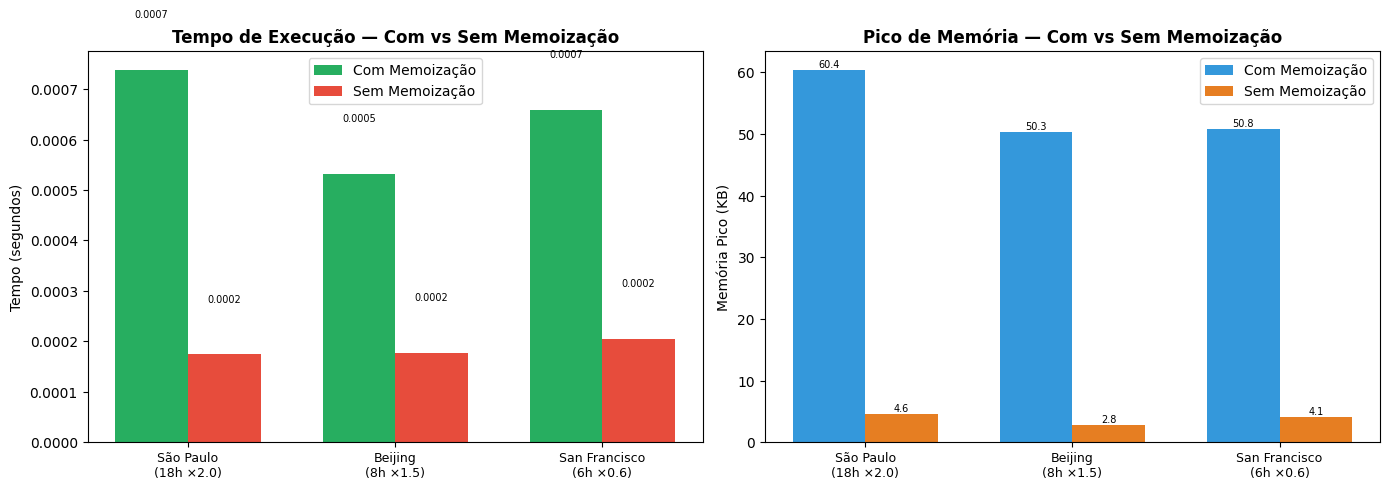

✅ Gráfico salvo como performance_comparison.png


In [10]:
cidades  = ["São Paulo\n(18h ×2.0)", "Beijing\n(8h ×1.5)", "San Francisco\n(6h ×0.6)"]
t_c      = [t_sp_c,   t_bj_c,   t_sf_c]
t_s      = [t_sp_s,   t_bj_s,   t_sf_s]
mem_c    = [mem_sp_c, mem_bj_c, mem_sf_c]
mem_s    = [mem_sp_s, mem_bj_s, mem_sf_s]

print("=" * 78)
print(f"{'Cidade':<22} {'T.Memo(s)':>10} {'T.SemMemo(s)':>14} {'Speedup':>9} "
      f"{'Mem.Memo(KB)':>13} {'Mem.Sem(KB)':>12}")
print("-" * 78)
for c, tm, ts, mm, ms in zip(["São Paulo","Beijing","San Francisco"], t_c, t_s, mem_c, mem_s):
    speedup = ts / tm if tm > 0 else 999
    print(f"{c:<22} {tm:>10.5f} {ts:>14.5f} {speedup:>8.1f}x {mm:>13.2f} {ms:>12.2f}")
print("=" * 78)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
x = range(len(cidades))
w = 0.35

# Tempo
ax = axes[0]
b1 = ax.bar([i - w/2 for i in x], t_c, w, label='Com Memoização', color='#27ae60')
b2 = ax.bar([i + w/2 for i in x], t_s, w, label='Sem Memoização', color='#e74c3c')
ax.set_title('Tempo de Execução — Com vs Sem Memoização', fontweight='bold')
ax.set_ylabel('Tempo (segundos)')
ax.set_xticks(list(x)); ax.set_xticklabels(cidades, fontsize=9)
ax.legend()
for bar in list(b1) + list(b2):
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 0.0001, f'{h:.4f}',
            ha='center', va='bottom', fontsize=7)

# Memória
ax = axes[1]
b3 = ax.bar([i - w/2 for i in x], mem_c, w, label='Com Memoização', color='#3498db')
b4 = ax.bar([i + w/2 for i in x], mem_s, w, label='Sem Memoização', color='#e67e22')
ax.set_title('Pico de Memória — Com vs Sem Memoização', fontweight='bold')
ax.set_ylabel('Memória Pico (KB)')
ax.set_xticks(list(x)); ax.set_xticklabels(cidades, fontsize=9)
ax.legend()
for bar in list(b3) + list(b4):
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 0.1, f'{h:.1f}',
            ha='center', va='bottom', fontsize=7)

plt.tight_layout()
plt.savefig("performance_comparison.png", dpi=130, bbox_inches='tight')
plt.show()
print("✅ Gráfico salvo como performance_comparison.png")


## 🔬 Análise de Complexidade e Conclusões

### Complexidade Algorítmica

| Algoritmo | Tempo | Espaço | Observação |
|-----------|-------|--------|------------|
| Menor custo **com** memoização | O(V × 2ᵛ) | O(V × 2ᵛ) | Estados únicos: (nó, frozenset visitados) |
| Menor custo **sem** memoização | O(V!) | O(V) | Recalcula subproblemas repetidamente |
| Maior custo (backtracking) | O(V!) | O(V) | Explora todos os caminhos simples |

Onde **V** = número de vértices (estações).

### Conclusões

1. **Memoização** é fundamental para tornar a busca recursiva viável em grafos com mais de ~20 nós. Sem ela, o tempo cresce fatorialmente com o número de vértices.

2. **Programação Dinâmica** transforma o problema de O(V!) para O(V × 2ᵛ) — ainda exponencial no pior caso, mas ordens de magnitude melhor na prática.

3. **Fatores de horário** alteram os custos absolutos mas não necessariamente a topologia do caminho ótimo. Em grafos com pesos uniformes entre vizinhos, o caminho mais curto topológico permanece o mesmo independente do fator — o fator escala todos os pesos igualmente. Em grafos com pesos variados, o horário **pode** inverter qual caminho é mais curto.

4. **Caminho mais longo simples** é NP-difícil em grafos gerais; o backtracking é correto para grafos de tamanho moderado (~30–40 nós). Para redes reais com centenas de estações, seriam necessários algoritmos heurísticos (A*, Dijkstra, programação dinâmica em DAGs).

5. **Tradeoff memória × velocidade:** A memoização usa mais memória (armazena todos os estados), mas reduz o tempo dramaticamente. Para dispositivos com memória limitada, versões iterativas com tabelas DP menores seriam mais adequadas.


## 🕐 Teste Interativo — Informe o Horário de Partida

Execute a célula abaixo para recalcular os caminhos com qualquer horário que desejar.


In [11]:
def calcular_rota_interativa(cidade, grafo, origem, destino):
    faixas = {
        0.6: "🟢 Bônus — Madrugada (05h–07h)",
        1.0: "🔵 Normal (09h–17h)",
        1.5: "🟡 Pico Manhã (07h–09h)",
        2.0: "🔴 Pico Tarde (17h–20h)"
    }
    while True:
        try:
            hora = float(input(f"\n⏰ Horário de partida para {cidade} (0–23): "))
            if 0 <= hora < 24: break
            print("   Valor deve ser entre 0 e 23.")
        except ValueError:
            print("   Digite um número válido.")

    fator = fator_horario(hora)
    print(f"   Fator: ×{fator}  {faixas.get(fator, '')}")

    fn = make_menor_custo(grafo)
    fn.cache_clear()

    custo_c, cam_c = fn(origem, destino, hora)
    custo_l, cam_l = maior_custo(grafo, origem, destino, hora)

    print(f"\n   ✅ MAIS CURTO ({len(cam_c)} est., {custo_c:.1f} min):")
    print("   " + " → ".join(cam_c))
    print(f"\n   🔴 MAIS LONGO ({len(cam_l)} est., {custo_l:.1f} min):")
    print("   " + " → ".join(cam_l))

# Descomente para usar interativamente:
# calcular_rota_interativa("São Paulo",      grafo_sp, "Tucuruvi",          "Capão Redondo")
# calcular_rota_interativa("Beijing",        grafo_bj, "Sihui East",        "Xizhimen")
# calcular_rota_interativa("San Francisco",  grafo_sf, "Dublin/Pleasanton", "Daly City")

print("💡 Descomente uma das linhas acima para testar com horário personalizado.")


💡 Descomente uma das linhas acima para testar com horário personalizado.
